In [80]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import openmc

In [81]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters('../parametri.txt')


# --- Parametri Geometrici ---
R_CORE    = p['R_CORE']
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']

# --- Parametri Logici ---
R_PIPE    = p['R_PIPE']

# --- Parametri Pin/Lattice ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']
PITCH     = p['PITCH']

# --- Parametri Target ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']

# --- Sorgente e Simulazione ---
S             = p['S']

bin_ris       = p['bin_ris']

batches       = p['batches_fix']
particles     = p['particles_fix']

arricchimento = p['arricchimento']
mix = p['mix_acqua']
pressione_funzionamento = p['Pressione_funzionamento']

T_water_HZP = p['T_water_HZP']
T_fuel_HFP = p['T_fuel_HFP']
T_fuel_HZP = p['T_fuel_HZP']

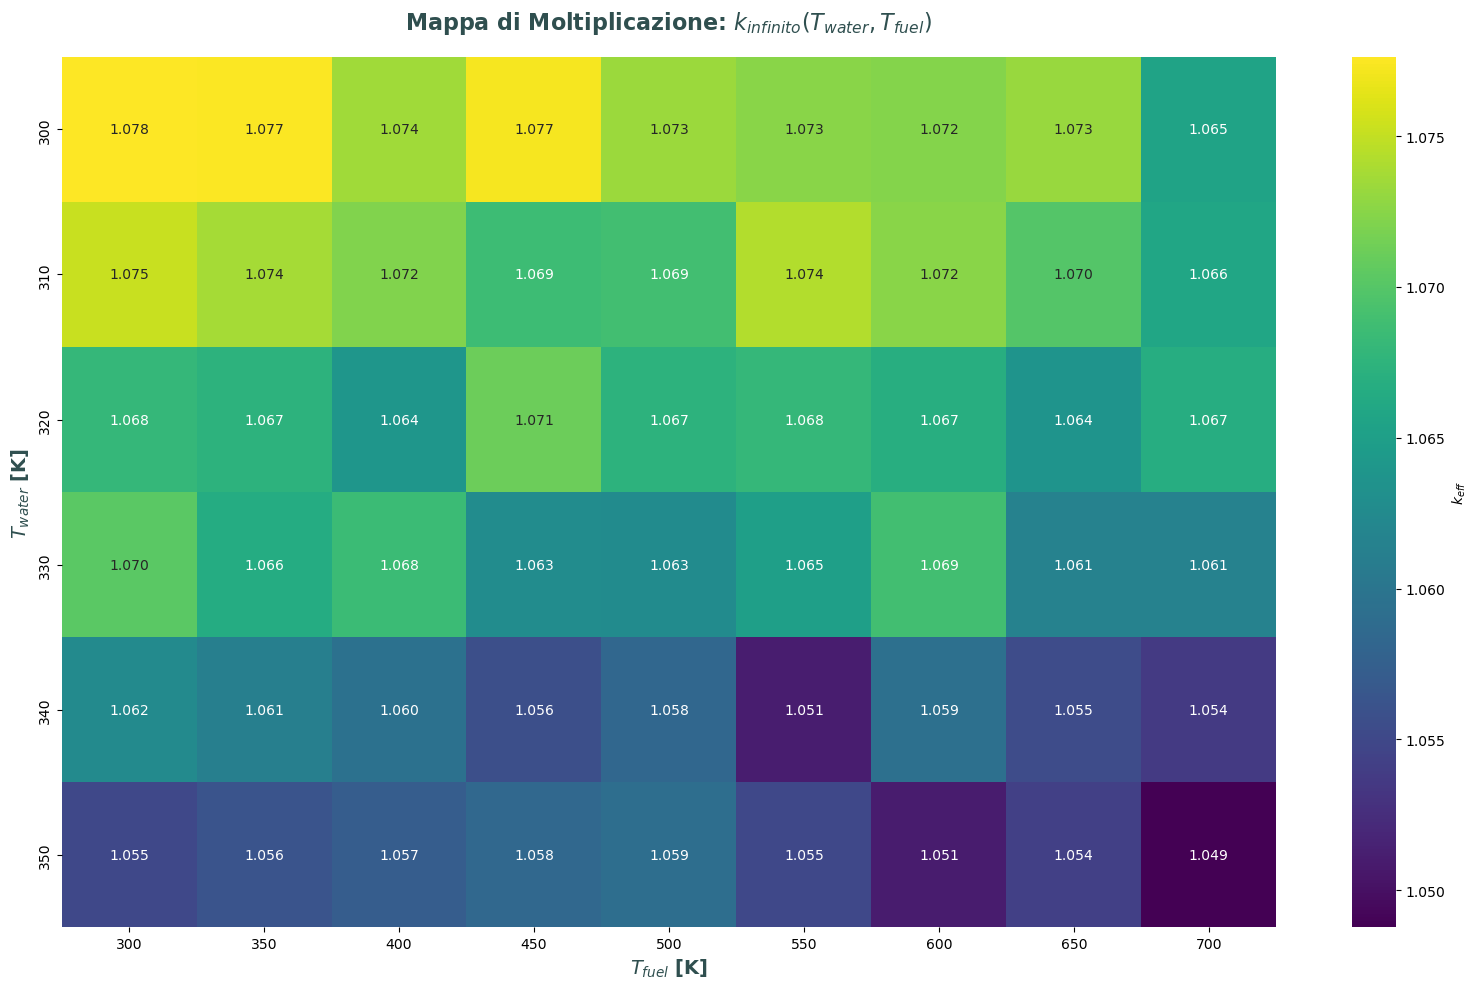

In [82]:
# 1. Parsing robusto del file di output
data = []
data_4_fact = []

path = "result/result.txt"

with open(path, "r") as f:
    for line in f:
        parts = line.strip().split()
        # Isolamento delle righe contenenti le 4 grandezze fisiche
        if len(parts) == 10:
            try:
                t_w = float(parts[0])
                t_f = float(parts[1])
                k = float(parts[2])
                err = float(parts[3])
                epsilon = float(parts[4])
                p = float(parts[5])
                f = float(parts[6])
                eta = float(parts[7])
                Leakage_Fraction = float(parts[8])
                k_inf_leakage = float(parts[9])
                data_4_fact.append([int(t_w), int(t_f), k_inf_leakage])
                data.append([int(t_w), int(t_f), k,err])
            except ValueError:
                continue

df = pd.DataFrame(data_4_fact, columns=['T_water', 'T_fuel', 'k_inf_leakage'])


# 2. Vettorizzazione 2D per la heatmap
heatmap_data = df.pivot(index='T_water', columns='T_fuel', values='k_inf_leakage')

# 3. Setup del plot (Standard Layout)
fig, ax = plt.subplots(figsize=(16, 10))

# Mappatura termica
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", ax=ax,
            cbar_kws={'label': '$k_{eff}$'})

# Formattazione Titolo e Labels
ax.set_title("Mappa di Moltiplicazione: $k_{infinito}(T_{water}, T_{fuel})$", fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
ax.set_xlabel("$T_{fuel}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("$T_{water}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')

plt.tight_layout()
plt.show()

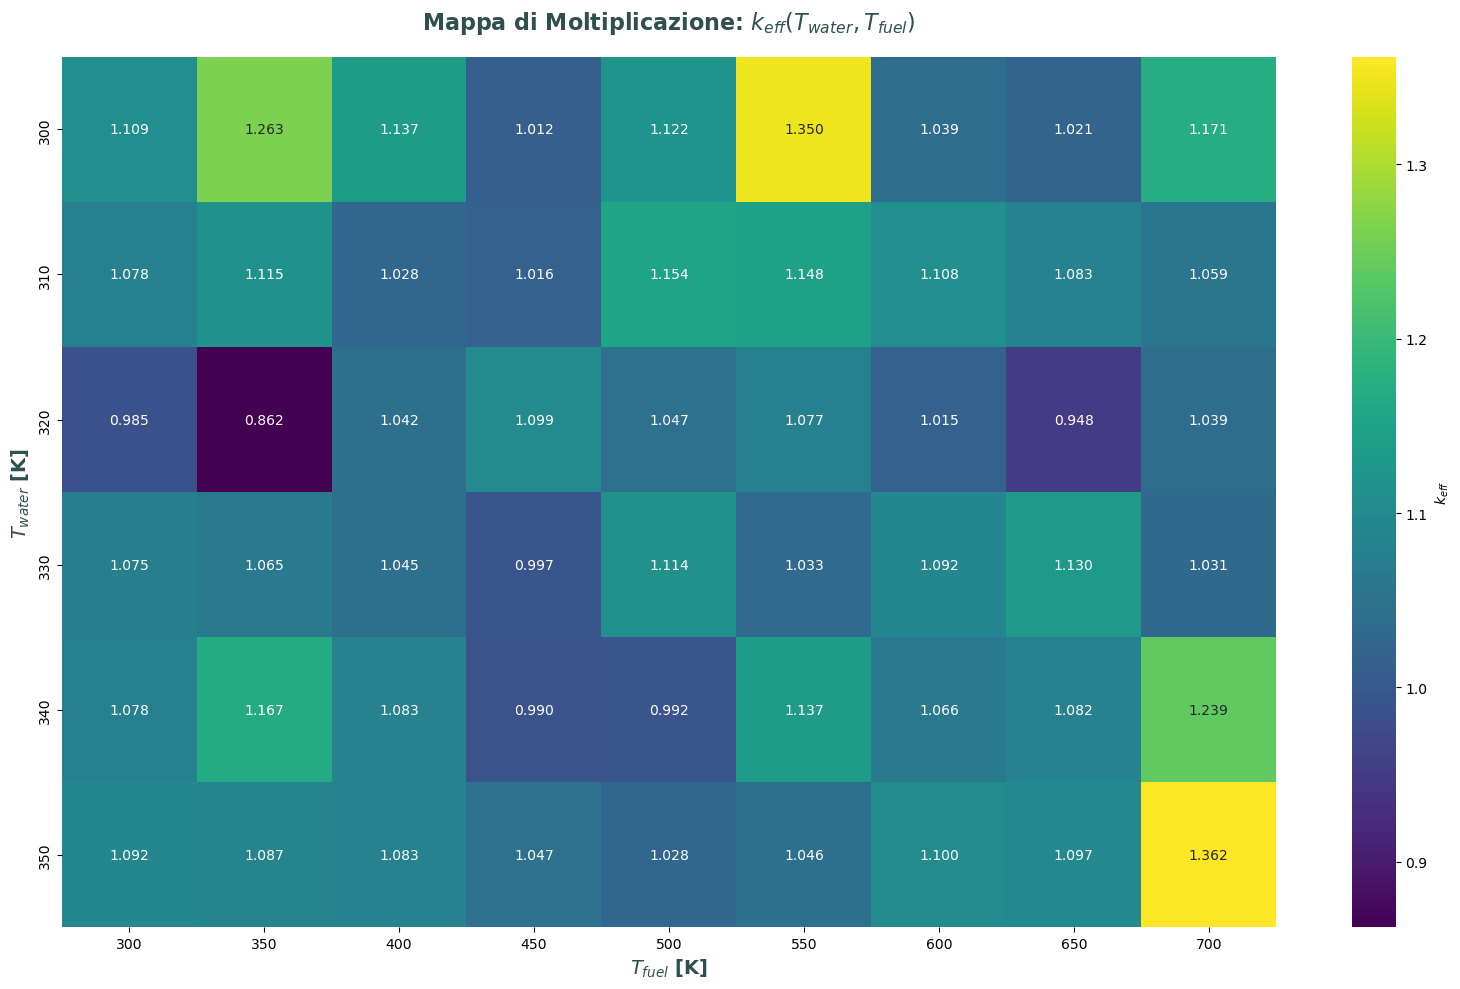

In [83]:
df = pd.DataFrame(data, columns=['T_water', 'T_fuel', 'k_eff', 'std_dev'])

# 2. Vettorizzazione 2D per la heatmap
heatmap_data = df.pivot(index='T_water', columns='T_fuel', values='k_eff')

# 3. Setup del plot (Standard Layout)
fig, ax = plt.subplots(figsize=(16, 10))

# Mappatura termica
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", ax=ax,
            cbar_kws={'label': '$k_{eff}$'})

# Formattazione Titolo e Labels
ax.set_title("Mappa di Moltiplicazione: $k_{eff}(T_{water}, T_{fuel})$", fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
ax.set_xlabel("$T_{fuel}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("$T_{water}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')

plt.tight_layout()
plt.show()

T_water = 300 K | m = -1.1746e-04 +/- 3.9387e-04 | q = 1.2004e+00 +/- 2.1538e-01
T_water = 310 K | m = -1.4023e-05 +/- 1.3363e-04 | q = 1.1083e+00 +/- 6.4798e-02
T_water = 320 K | m = 4.0297e-05 +/- 1.5029e-04 | q = 9.8399e-01 +/- 7.9394e-02
T_water = 330 K | m = 7.2946e-05 +/- 1.1414e-04 | q = 1.0270e+00 +/- 5.4699e-02
T_water = 340 K | m = -5.3916e-04 +/- 2.7575e-04 | q = 1.3032e+00 +/- 1.2785e-01
T_water = 350 K | m = 5.1051e-05 +/- 1.8062e-04 | q = 1.0353e+00 +/- 8.1274e-02


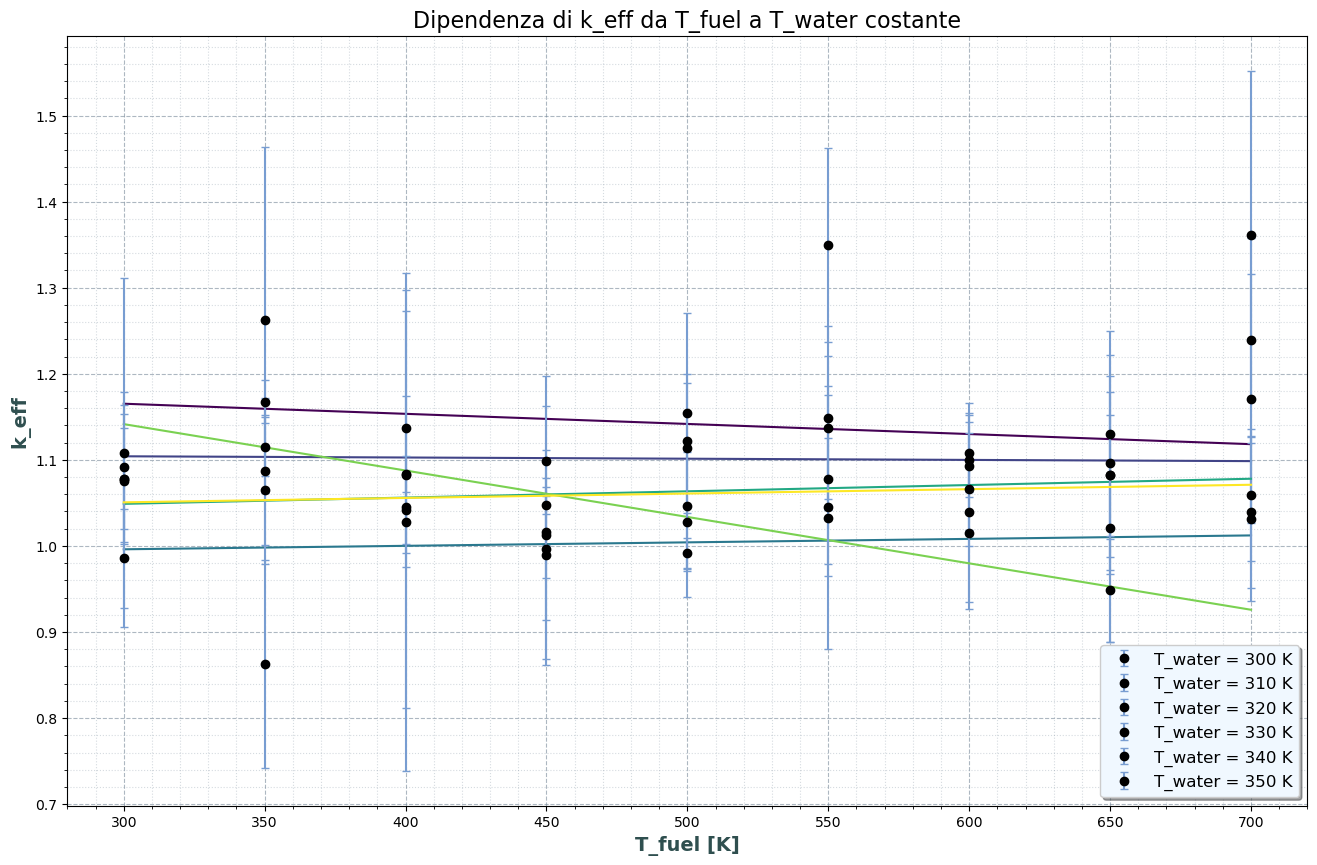

In [84]:
plt.figure(figsize=(16, 10))
t_waters = df['T_water'].unique()
colori_tw = plt.cm.viridis(np.linspace(0, 1, len(t_waters)))

m_values = []
err_m_values = []

for i, tw in enumerate(t_waters):
    df_sub = df[df['T_water'] == tw]
    x = df_sub['T_fuel']
    y = df_sub['k_eff']
    yerr = df_sub['std_dev']

    # Fit lineare pesato: y = m*x + q
    # Usiamo w = 1/yerr (np.polyfit richiede i pesi come 1/sigma)
    p, cov = np.polyfit(x, y, 1, w=1/yerr, cov=True)
    m, q = p
    err_m, err_q = np.sqrt(np.diag(cov))

    # Salvataggio dei coefficienti
    m_values.append(m)
    err_m_values.append(err_m)

    # Stampa dei parametri a schermo
    print(f"T_water = {tw:.0f} K | m = {m:.4e} +/- {err_m:.4e} | q = {q:.4e} +/- {err_q:.4e}")

    # Plot dei punti con barre d'errore
    plt.errorbar(x, y, yerr=yerr,
                 fmt='o', color=colori_tw[i],
                 markerfacecolor='#000000', markeredgecolor='#000000',
                 ecolor='#789DD1', capsize=3,
                 label=f'T_water = {int(tw)} K')

    # Plot della retta di fit
    plt.plot(x, np.polyval(p, x), '-', color=colori_tw[i])
    m_array = np.array(m_values)
    err_m_array = np.array(err_m_values)

plt.title('Dipendenza di k_eff da T_fuel a T_water costante', fontsize=16)
plt.xlabel('T_fuel [K]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('k_eff', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.minorticks_on()
plt.grid(True, which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(True, which='minor', linestyle=':', alpha=0.3, color='#778899')
plt.legend(loc='best', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.show()

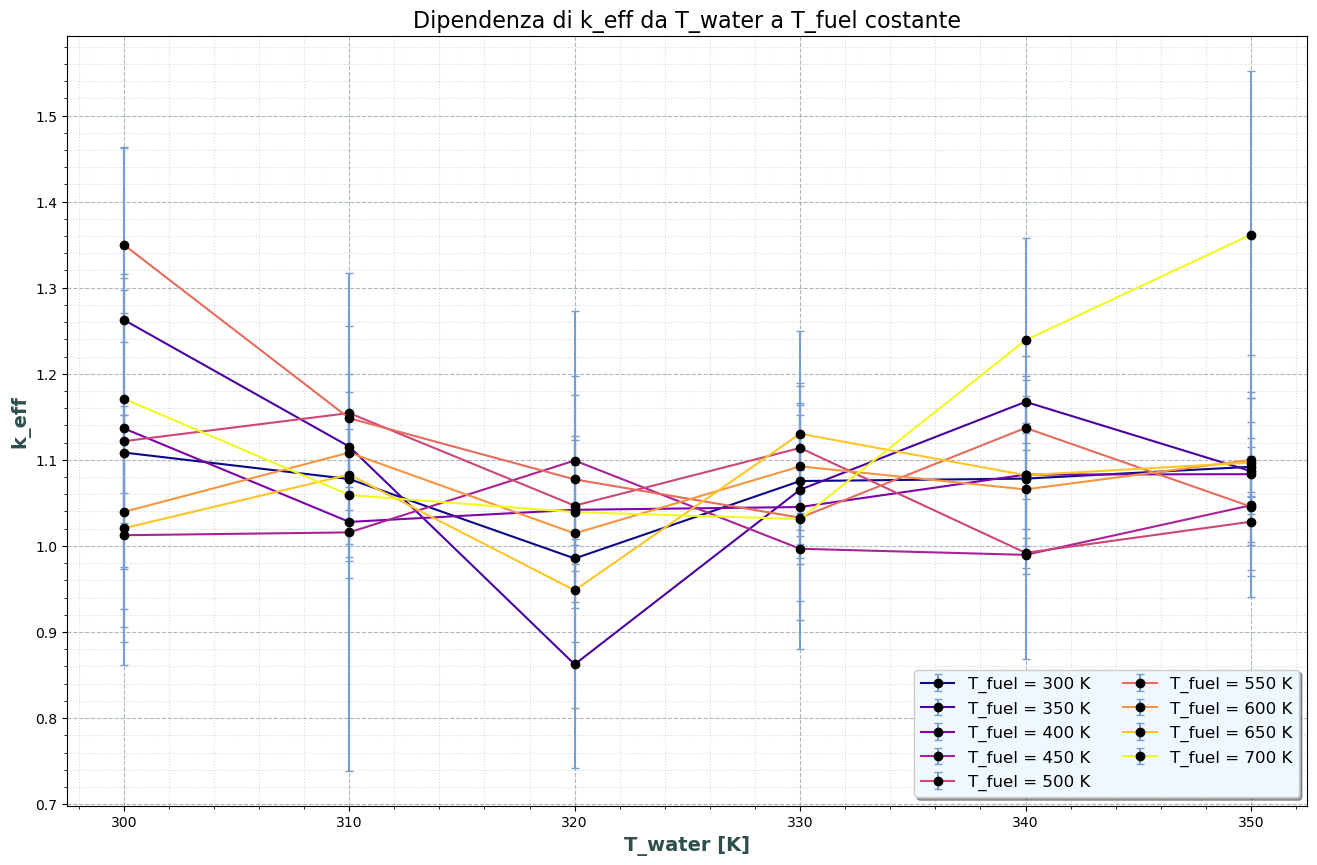

In [85]:
plt.figure(figsize=(16, 10))
t_fuels = df['T_fuel'].unique()
colori_tf = plt.cm.plasma(np.linspace(0, 1, len(t_fuels)))

for i, tf in enumerate(t_fuels):
    df_sub = df[df['T_fuel'] == tf]
    plt.errorbar(df_sub['T_water'], df_sub['k_eff'], yerr=df_sub['std_dev'],
                 fmt='o-', color=colori_tf[i],
                 markerfacecolor='#000000', markeredgecolor='#000000',
                 ecolor='#789DD1', capsize=3,
                 label=f'T_fuel = {int(tf)} K')

plt.title('Dipendenza di k_eff da T_water a T_fuel costante', fontsize=16)
plt.xlabel('T_water [K]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('k_eff', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.minorticks_on()
plt.grid(True, which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(True, which='minor', linestyle=':', alpha=0.3, color='#778899')
plt.legend(loc='best', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF', ncol=2)

plt.show()

- Assumo che il reattore spento stia a 300 K sia in fuel che in acqua Cold Zero Power (CZP)

- definisco poi l'Hot Zero Power, cioè T_fuel = T_water ma a valori maggiori, magari 550K, cioè reattore pronto all'uso ma con ancora nessuna potenza prodotta

- infine serve il HFP = hot full power, cioè massima potenza


Per vedere una variazione:
$$\Delta\rho = \rho_2 - \rho_1 = \frac{k_2 - 1}{k_2} - \frac{k_1 - 1}{k_1} = \frac{k_2 - k_1}{k_1 \cdot k_2}$$


1. Temperature Defect (CZP $\rightarrow$ HZP) Nello stato CZP ($300\text{ K}$), il sistema è freddo. 
L'acqua ha la massima densità, offrendo la massima moderazione (spettro neutronico fortemente termico).
Scaldando il sistema allo stato HZP ($550\text{ K}$), la potenza è ancora nulla, quindi l'equilibrio termico impone $T_{fuel} = T_{water}$. 
    1) Il calo di reattività associato (Temperature Defect) è causato da due contributi: Moderator Temperature Coefficient (MTC) [Dominante]: All'aumentare della temperatura, la densità dell'acqua crolla. Questo causa due effetti: 
    - Diminuisce il potere rallentante ($\xi \Sigma_s$), indurendo lo spettro neutronico. Più neutroni vengono assorbiti nelle risonanze epitemiche dell'$^{238}\text{U}$ prima di termalizzare.
    - Aumenta il cammino libero medio neutronico, incrementando le fughe (leakage) verso i bordi del nocciolo.
    
    2) Effetto Doppler Isotermo [Minoritario]: Anche il combustibile si scalda da $300\text{ K}$ a $550\text{ K}$, causando un primo allargamento delle risonanze di assorbimento (Doppler broadening). 

2. Power Defect (HZP $\rightarrow$ HFP) Allo stato HZP, il reattore è critico e alle condizioni nominali di pressione/temperatura del fluido, ma genera $0\text{ W}$.Portando il reattore allo stato HFP (100% potenza nominale), la temperatura del moderatore resta approssimativamente costante ($T_{water} \approx 550\text{ K}$ media), ma per trasferire l'enorme calore generato per fissione nel pellet verso il fluido, si instaura un ripido gradiente termico. La temperatura media del combustibile $T_{fuel}$ schizza a valori elevati (es. $900\text{ K}$).Il calo di reattività associato (Power Defect) è dominato esclusivamente da un fenomeno: Fuel Temperature Coefficient (FTC) o Effetto Doppler Puro: L'aumento drammatico dell'agitazione termica dei nuclei di $^{238}\text{U}$ nel reticolo cristallino dell'$UO_2$ causa un allargamento (broadening) delle sezioni d'urto di cattura risonante. Sebbene l'integrale dell'area sotto la risonanza resti teoricamente costante, l'allargamento abbassa i picchi e allarga le code (riducendo il self-shielding spaziale ed energetico). Di conseguenza, aumenta drasticamente la probabilità che un neutrone venga catturato parassiticamente dall'$^{238}\text{U}$ durante il rallentamento.Il Power Defect rappresenta il feedback negativo vitale per la stabilità e la sicurezza intrinseca del reattore: all'aumentare della potenza, la fisica stessa del nocciolo "spegne" la reazione a catena. Questo valore definisce quanta reattività (es. estraendo le barre di controllo) l'operatore deve inserire per poter effettivamente far salire il reattore da $0$ al $100\%$ di potenza.


- Temperature Defect (Moderatore + Doppler base): Transizione da CZP a HZP.
$$\Delta\rho_{temp}=\frac{k_{HZP}-k_{CZP}}{k_{HZP}\cdot k_{CZP}}\cdot 10^5\quad [pcm]$$

- Power Defect (Effetto Doppler puro): Transizione da HZP a HFP.
$$\Delta\rho_{power}=\frac{k_{HFP}-k_{HZP}}{k_{HFP}\cdot k_{HZP}}\cdot 10^5\quad [pcm]$$

In [86]:
def calc_reactivity_defect(k1, std1, k2, std2):
    """Calcola il delta_rho in pcm e propaga l'errore statistico."""
    delta_rho = ((k2 - k1) / (k1 * k2)) * 1e5
    
    # Propagazione dell'errore per f(k1, k2) = 1/k1 - 1/k2
    err_rho = np.sqrt((std1**2 / k1**4) + (std2**2 / k2**4)) * 1e5
    
    return delta_rho, err_rho

def get_k_state(df, tw, tf):
    """Recupera k_eff e std_dev per una data coppia di temperature."""
    row = df[(df['T_water'] == tw) & (df['T_fuel'] == tf)]
    if not row.empty:
        return row['k_eff'].values[0], row['std_dev'].values[0]
    else:
        raise ValueError(f"Stato (Tw={tw}K, Tf={tf}K) non trovato nei dati.")


# Definizione degli stati (Modifica T_fuel_hfp in base al calcolo termoidraulico)
T_water_czp, T_fuel_czp = 300, 300

# Estrazione k_eff
k_czp, std_czp = get_k_state(df, T_water_czp, T_fuel_czp)
k_hzp, std_hzp = get_k_state(df, T_water_HZP, T_fuel_HZP)
k_hfp, std_hfp = get_k_state(df, T_water_HZP, T_fuel_HFP)

# Calcolo Difetti
rho_temp, err_temp = calc_reactivity_defect(k_czp, std_czp, k_hzp, std_hzp)
rho_pow, err_pow = calc_reactivity_defect(k_hzp, std_hzp, k_hfp, std_hfp)

ignorancy = -200 # Placeholder per l'ignoranza sui dati nucleari

# Stampa Risultati Scientifici
print("=== STATI OPERATIVI ===")
print(f"CZP (Tw={T_water_czp}K, Tf={T_fuel_czp}K): k = {k_czp:.5f} +/- {std_czp:.5f}")
print(f"HZP (Tw={T_water_HZP}K, Tf={T_fuel_HZP}K): k = {k_hzp:.5f} +/- {std_hzp:.5f}")
print(f"HFP (Tw={T_water_HZP}K, Tf={T_fuel_HFP}K): k = {k_hfp:.5f} +/- {std_hfp:.5f}\n")

print("=== DIFETTI DI REATTIVITA' ===")
print(f"Temperature Defect (CZP -> HZP) : {rho_temp:>7.1f} +/- {err_temp:.1f} pcm")
print(f"Power Defect       (HZP -> HFP) : {rho_pow:>7.1f} +/- {err_pow:.1f} pcm")
print(f"Ignoranza sui dati nucleari : {ignorancy:.1f} pcm") # Placeholder per l'ignoranza sui dati nucleari
print(f"Total Defect       (CZP -> HFP) : {(rho_temp + rho_pow + ignorancy):>7.1f} +/- {np.sqrt(err_temp**2 + err_pow**2):.1f} pcm")

=== STATI OPERATIVI ===
CZP (Tw=300K, Tf=300K): k = 1.10851 +/- 0.20322
HZP (Tw=350K, Tf=350K): k = 1.08681 +/- 0.08552
HFP (Tw=350K, Tf=600K): k = 1.09999 +/- 0.04369

=== DIFETTI DI REATTIVITA' ===
Temperature Defect (CZP -> HZP) : -1801.2 +/- 18053.6 pcm
Power Defect       (HZP -> HFP) :  1102.5 +/- 8090.8 pcm
Ignoranza sui dati nucleari : -200.0 pcm
Total Defect       (CZP -> HFP) :  -898.7 +/- 19783.7 pcm


In [87]:
#calcolo ora K_max 

rho_max = rho_temp + rho_pow + ignorancy 
k_max = 1 / (1 - rho_max/1e5)
print(f"\n--- K_max stimato ---")
print(f"K_max stimato: {k_max:.5f}")


--- K_max stimato ---
K_max stimato: 0.99109
